# **Banking:**

Let start by importing all the neccessary libraries that wil lbe used throughout the project for data manipulation, visualization, and modeling.

In [122]:
#Data Analysis
import pandas as pd
import numpy as np

#visualization

import matplotlib.pyplot as plt
import seaborn as sns

#machine learning models nd utilities

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE # Library for handling imbalanced datasets

#set seaborn style

sns.set(style='whitegrid')


**1 - Data Understanding and preparation**

A - Read both the Datasets ‘Data1’ and ‘Data 2’ as DataFrame and store them into two separate variables.

In [82]:
#Read both data set

df1 = pd.read_csv('/content/drive/MyDrive/GL_AIML/LinearRegression/ProjectWork/Part2/Part2_Data1.csv')
df2 = pd.read_csv('/content/drive/MyDrive/GL_AIML/LinearRegression/ProjectWork/Part2/Part2_Data2.csv')

B - Print shape and Column Names and DataTypes of both the Dataframes.

In [84]:
print("Shape of df1:", df1.shape)
print("Shape of df2:", df2.shape)
print("Columns of df1:\n", df1.columns)
print("Columns of df2:\n", df2.columns)
print("\nData types of df1:", df1.dtypes)
print("\nData types of df2:", df1.dtypes)

Shape of df1: (5000, 8)
Shape of df2: (5000, 7)
Columns of df1:
 Index(['ID', 'Age', 'CustomerSince', 'HighestSpend', 'ZipCode', 'HiddenScore',
       'MonthlyAverageSpend', 'Level'],
      dtype='object')
Columns of df2:
 Index(['ID', 'Mortgage', 'Security', 'FixedDepositAccount', 'InternetBanking',
       'CreditCard', 'LoanOnCard'],
      dtype='object')

Data types of df1: ID                       int64
Age                      int64
CustomerSince            int64
HighestSpend             int64
ZipCode                  int64
HiddenScore              int64
MonthlyAverageSpend    float64
Level                    int64
dtype: object

Data types of df2: ID                       int64
Age                      int64
CustomerSince            int64
HighestSpend             int64
ZipCode                  int64
HiddenScore              int64
MonthlyAverageSpend    float64
Level                    int64
dtype: object


In [85]:
df1.head()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level
0,1,25,1,49,91107,4,1.6,1
1,2,45,19,34,90089,3,1.5,1
2,3,39,15,11,94720,1,1.0,1
3,4,35,9,100,94112,1,2.7,2
4,5,35,8,45,91330,4,1.0,2


In [86]:
df2.head()

,ID,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,0,1,0,0,0,NaN
1,2,0,1,0,0,0,NaN
2,3,0,0,0,0,0,NaN
3,4,0,0,0,0,0,NaN
4,5,0,0,0,0,1,NaN


C - Merge both the Dataframes on ‘ID’ feature to form a single DataFrame

In [90]:
# Merge DataFrames
merged_data = pd.merge(df1, df2, on='ID')
merged_data.head()


,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,25,1,49,91107,4,1.6,1,0,1,0,0,0,NaN
1,2,45,19,34,90089,3,1.5,1,0,1,0,0,0,NaN
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,NaN
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,NaN
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,1,NaN


In [91]:
merged_data.describe()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,4980.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.104400,0.06040,0.596800,0.294000,0.096386
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.305809,0.23825,0.490589,0.455637,0.295149
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.00000,1.000000,1.000000,0.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.00000,1.000000,1.000000,1.000000


D - Change Datatype of below features to ‘Object’

‘CreditCard’, ‘InternetBanking’, ‘FixedDepositAccount’, ‘Security’, ‘Level’, ‘HiddenScore’.

In [92]:
# Changing data types
features_to_change = ['CreditCard', 'InternetBanking', 'FixedDepositAccount', 'Security', 'Level', 'HiddenScore']
merged_data[features_to_change] = merged_data[features_to_change].astype('object')


In [93]:
print("Data types of merged_data:", merged_data.dtypes)


Data types of merged_data: ID                       int64
Age                      int64
CustomerSince            int64
HighestSpend             int64
ZipCode                  int64
HiddenScore             object
MonthlyAverageSpend    float64
Level                   object
Mortgage                 int64
Security                object
FixedDepositAccount     object
InternetBanking         object
CreditCard              object
LoanOnCard             float64
dtype: object


**2 - Data Exploration and Analysis**

Visualize distribution of Target variable ‘LoanOnCard’ and clearly share insights.

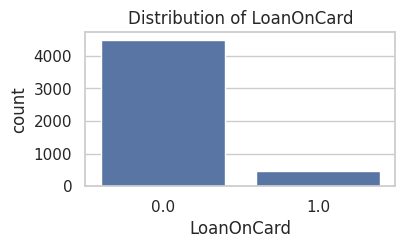

In [95]:


# Visualize distribution\
plt.figure(figsize=(4,2))
sns.countplot(data=merged_data, x='LoanOnCard')
plt.title('Distribution of LoanOnCard')
plt.show()


Insights:

This plot shows a significant imbalance between the classes.

No of customer who doesnot have loan on their credit card , class = 0 , is much higher than class =1. This shows strong imbalance in dataset.

**B - Check the percentage of missing values and impute if required**

In [96]:
# Check missing values
missing_values = merged_data.isnull().mean() * 100
print("Percentage of missing values:\n", missing_values)

# Impute missing values if necessary
# Example imputation (mean for numerical, mode for categorical)
for col in merged_data.columns:
    if merged_data[col].dtype == 'object':
        merged_data[col].fillna(merged_data[col].mode()[0], inplace=True)
    else:
        merged_data[col].fillna(merged_data[col].mean(), inplace=True)


Percentage of missing values:
 ID                     0.0
Age                    0.0
CustomerSince          0.0
HighestSpend           0.0
ZipCode                0.0
HiddenScore            0.0
MonthlyAverageSpend    0.0
Level                  0.0
Mortgage               0.0
Security               0.0
FixedDepositAccount    0.0
InternetBanking        0.0
CreditCard             0.0
LoanOnCard             0.4
dtype: float64


C - Check for unexpected values in each categorical variable and impute

In [97]:
# Checking and imputing unexpected values
for col in features_to_change:
    unexpected_values = merged_data[~merged_data[col].isin([0, 1])][col].unique()
    print(f"Unexpected values in {col}:", unexpected_values)
    # Impute unexpected values
    merged_data[col] = pd.to_numeric(merged_data[col], errors='coerce').fillna(merged_data[col].mode()[0])


Unexpected values in CreditCard: []
Unexpected values in InternetBanking: []
Unexpected values in FixedDepositAccount: []
Unexpected values in Security: []
Unexpected values in Level: [2 3]
Unexpected values in HiddenScore: [4 3 2]


**3 - Data Preparation and model building**

A - Split data into X and Y

In [98]:
# Drop ID and ZipCode, and separate target variable
X = merged_data.drop(columns=['ID', 'ZipCode', 'LoanOnCard'])
y = merged_data['LoanOnCard']


B - Split data into train and test. Keep 25% data reserved for testing.

In [99]:
#spliting data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


C - Train a Supervised Learning Classification base model - Logistic Regression.

In [100]:
# Train model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

ValueError: Unknown label type: 'continuous'

In [104]:
# Check the data type of y_train
print(y_train.dtype)

# If it's not an integer type, convert it
if y_train.dtype not in ['int32', 'int64']:
    y_train = y_train.astype(int)

# Train model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

int64


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

D - Print evaluation metrics for the model and clearly share insights.

In [106]:
# Predict and evaluate
y_pred = log_reg.predict(X_test)

# Check data types and convert if necessary
if y_test.dtype not in ['int32', 'int64']:
    y_test = y_test.astype(int)
if y_pred.dtype not in ['int32', 'int64']:
    y_pred = y_pred.astype(int)

print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1116
           1       0.91      0.57      0.70       134

    accuracy                           0.95      1250
   macro avg       0.93      0.78      0.84      1250
weighted avg       0.95      0.95      0.94      1250

Accuracy: 0.948


**Insights:**

**Accuracy:** - 94.8%, Since the accuracy percentage is quite high about 95%. It means this model can predict correctly about 95 time out of every 100 instances in the test set.

**Class Imbalance:** Model shows that a clear disparity in performance between the majority and minor classes. It suggests that the model might be biased towards the majority classes.

Its strong at identifying the class 0 (majority class) with precision and recall both more than 90%. Whereas the performance on the class 1 (minority class) is lower especially in terms of recall (57%)

**E - Balance the data using the right balancing technique.**

i. Check distribution of the target variable

ii. Say output is class A : 20% and class B :
80%

iii. Here you need to balance the target variable as 50:50.

iv. Try appropriate method to achieve the same.

In [108]:
from imblearn.over_sampling import SMOTE

#Balancing the target variable

smote = SMOTE(random_state=42)
X_train_balance, y_train_balance = smote.fit_resample(X_train, y_train)

#Distribution of the target variable after balancing

print("Distribution of target variable after balancing:", y_train_bal.value_counts())

Distribution of target variable after balancing: LoanOnCard
0    3404
1    3404
Name: count, dtype: int64


F - Again train the same previous model on balanced data

In [109]:
#Train model on balanced data
log_reg_bal = LogisticRegression()
log_reg_bal.fit(X_train_balance, y_train_balance)



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

G - Print evaluation metrics and clearly share differences observed

In [110]:
#Predict and evaluate on balanced data

y_pred_bal = log_reg_bal.predict(X_test)

print("Logistic Regression on the balanced classification report:", classification_report(y_test, y_pred_bal))
print("Accuracy on the balanced data:", accuracy_score(y_test, y_pred_bal))

Logistic Regression on the balanced classification report:               precision    recall  f1-score   support

           0       0.98      0.87      0.92      1116
           1       0.44      0.83      0.57       134

    accuracy                           0.87      1250
   macro avg       0.71      0.85      0.75      1250
weighted avg       0.92      0.87      0.88      1250

Accuracy on the balanced data: 0.868


Difference Observed:

Overall performance and weighted average F1-Score have decreased after balancing.

Class 0: Precision for class 0 has been improved but recall dropped significantly.

Class 1: Recall for class 1 has improved , precision of class1 has dropped .

# **4. Performance Improvement**

A - Train a base model each for SVM, KNN

In [115]:
#Train SVM Model
svm_model = SVC()
svm_model.fit(X_train, y_train)

#Train KNN Model
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)


KNeighborsClassifier()

B - Tune parameters for each of the models wherever required and finalize a model

In [116]:
# Tune KNN parameters
knn_params = {'n_neighbors': [3, 5, 7]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7]})

In [117]:
# Tune SVM parameters
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(), svm_params, cv=5)
svm_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']})

In [118]:
# Best models
best_svm = svm_grid.best_estimator_
best_knn = knn_grid.best_estimator_

C - Print evaluation metrics for final model.

In [120]:
#Printing evaluation metrics for final model

#Evaluate KNN

y_pred_knn = best_knn.predict(X_test)
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("KNN Accuracy:\n", accuracy_score(y_test, y_pred_knn))

#Evaluate SVM

y_pred_svm = best_svm.predict(X_test)
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Accuracy:\n", accuracy_score(y_test, y_pred_svm))

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      1116
           1       0.59      0.34      0.43       134

    accuracy                           0.90      1250
   macro avg       0.76      0.66      0.69      1250
weighted avg       0.89      0.90      0.89      1250

KNN Accuracy:
 0.904
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1116
           1       0.91      0.62      0.74       134

    accuracy                           0.95      1250
   macro avg       0.93      0.81      0.86      1250
weighted avg       0.95      0.95      0.95      1250

SVM Accuracy:
 0.9528


D - Share improvement achieved from base model to final model

In [121]:
# Improvement insights
print("Improvement from Logistic Regression to SVM/KNN:\n")
print("SVM Accuracy Improvement:", accuracy_score(y_test, y_pred_svm) - accuracy_score(y_test, y_pred))
print("KNN Accuracy Improvement:", accuracy_score(y_test, y_pred_knn) - accuracy_score(y_test, y_pred))


Improvement from Logistic Regression to SVM/KNN:

SVM Accuracy Improvement: 0.0048000000000000265
KNN Accuracy Improvement: -0.04399999999999993


**Ovberall insights:**

**1. Initial Logistic Regression Model Metrics:**

Accuracy: 0.948
Precision and Recall for class 1:
Precision: 0.91
Recall: 0.57
F1-score for class 1: 0.70

**2. Logistic Regression on Balanced Data Metrics:**

Accuracy on Balanced Data: 0.868
Precision and Recall for class 1:
Precision: 0.44
Recall: 0.83
F1-score for class 1: 0.57


**3. SVM Model Metrics:**
Accuracy: 0.9528
Precision and Recall for class 1:
Precision: 0.91
Recall: 0.62
F1-score for class 1: 0.74

**4. KNN Model Metrics:**
Accuracy: 0.904
Precision and Recall for class 1:
Precision: 0.59
Recall: 0.34
F1-score for class 1: 0.43

**Improvements:**

Accuracy Improvement:
SVM: 0.0048
KNN: −0.044 (decrease)

**Conclusion:**

SVM shows a slight improvement in accuracy and substantial improvements in precision and recall for class 1 compared to the base Logistic Regression model.

KNN does not perform as well as Logistic Regression in terms of accuracy and it has lower precision and recall for class 1.


**The SVM model shows the most significant improvement in accuracy and performance metrics, in precision and recall for class 1 as well, It shows that SVM is the preferred model choice among the ones calculated.**
